# 🫁 RSNA Pneumonia Detection — YOLOv8 + Grad-CAM

**Pipeline:**
1. Install dependencies
2. Download dataset (kagglehub)
3. Load & explore CSV
4. Filter classes
5. Preview X-rays
6. Convert to YOLO format
7. Train YOLOv8
8. Training curves
9. Evaluate (mAP, Precision, Recall)
10. Grad-CAM visualization
11. Inference demo

> ⚠️ Runtime → Change runtime type → **T4 GPU** before running.

## 📦 Step 1 — Install dependencies

In [7]:
!pip install -q ultralytics opencv-python-headless
import ultralytics
ultralytics.checks()

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


## 🔑 Step 2 — Kaggle credentials

Go to [kaggle.com/settings](https://www.kaggle.com/settings) → API section → copy your username and key.

In [8]:
# ✅ On Kaggle no credentials needed — dataset is directly accessible
print("✅ Running on Kaggle — no credentials needed")

✅ Running on Kaggle — no credentials needed


## 📥 Step 3 — Download dataset

In [9]:
import kagglehub, os

path = kagglehub.dataset_download("iamtapendu/rsna-pneumonia-processed-dataset")
DATA_DIR = path
IMG_DIR  = f'{DATA_DIR}/Training'

print("Dataset path:", DATA_DIR)
print("\n📂 Files:")
for f in os.listdir(DATA_DIR):
    print(' ', f)

Dataset path: /kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset

📂 Files:
  stage2_train_metadata.csv
  stage2_test_metadata.csv
  Training
  Test


## 📊 Step 4 — Load & explore CSV

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = f'{DATA_DIR}/stage2_train_metadata.csv'
df = pd.read_csv(CSV_PATH)

print(f"Total rows     : {len(df)}")
print(f"Unique patients: {df['patientId'].nunique()}")
print(f"\nClass distribution:")
print(df['class'].value_counts())
print(f"\nTarget distribution:")
print(df['Target'].value_counts())

df.head()

Total rows     : 30227
Unique patients: 26684

Class distribution:
class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

Target distribution:
Target
0    20672
1     9555
Name: count, dtype: int64


,patientId,x,y,width,height,Target,class,age,sex,modality,position
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,51,F,CR,PA
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,48,F,CR,PA
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal,19,M,CR,AP
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0,Normal,28,M,CR,PA
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1,Lung Opacity,32,F,CR,AP


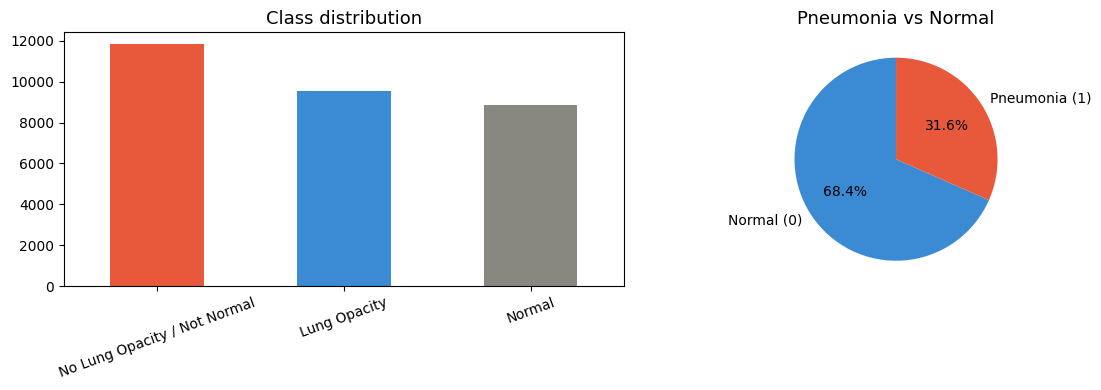

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['class'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#E8593C','#3B8BD4','#888780'], edgecolor='none'
)
axes[0].set_title('Class distribution', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

df['Target'].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['Normal (0)', 'Pneumonia (1)'],
    colors=['#3B8BD4','#E8593C'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Pneumonia vs Normal', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 🔍 Step 5 — Filter classes

Keep only **Lung Opacity** (pneumonia) and **Normal**. Drop `No Lung Opacity / Not Normal` to keep the task clean binary.

In [12]:
df_filtered = df[df['class'].isin(['Lung Opacity', 'Normal'])].copy()

patients_pneumonia = df_filtered[df_filtered['Target'] == 1]['patientId'].unique()
patients_normal    = df_filtered[df_filtered['Target'] == 0]['patientId'].unique()

print(f"Pneumonia patients : {len(patients_pneumonia)}")
print(f"Normal patients    : {len(patients_normal)}")
print(f"Total              : {len(patients_pneumonia) + len(patients_normal)}")
print(f"\nRatio pneumonia    : {len(patients_pneumonia)/(len(patients_pneumonia)+len(patients_normal))*100:.1f}%")
print("\n⚠️  Class imbalance present — handled via cls=2.0 weight during training")

Pneumonia patients : 6012
Normal patients    : 8851
Total              : 14863

Ratio pneumonia    : 40.4%

⚠️  Class imbalance present — handled via cls=2.0 weight during training


## 🖼️ Step 6 — Preview X-rays with bounding boxes

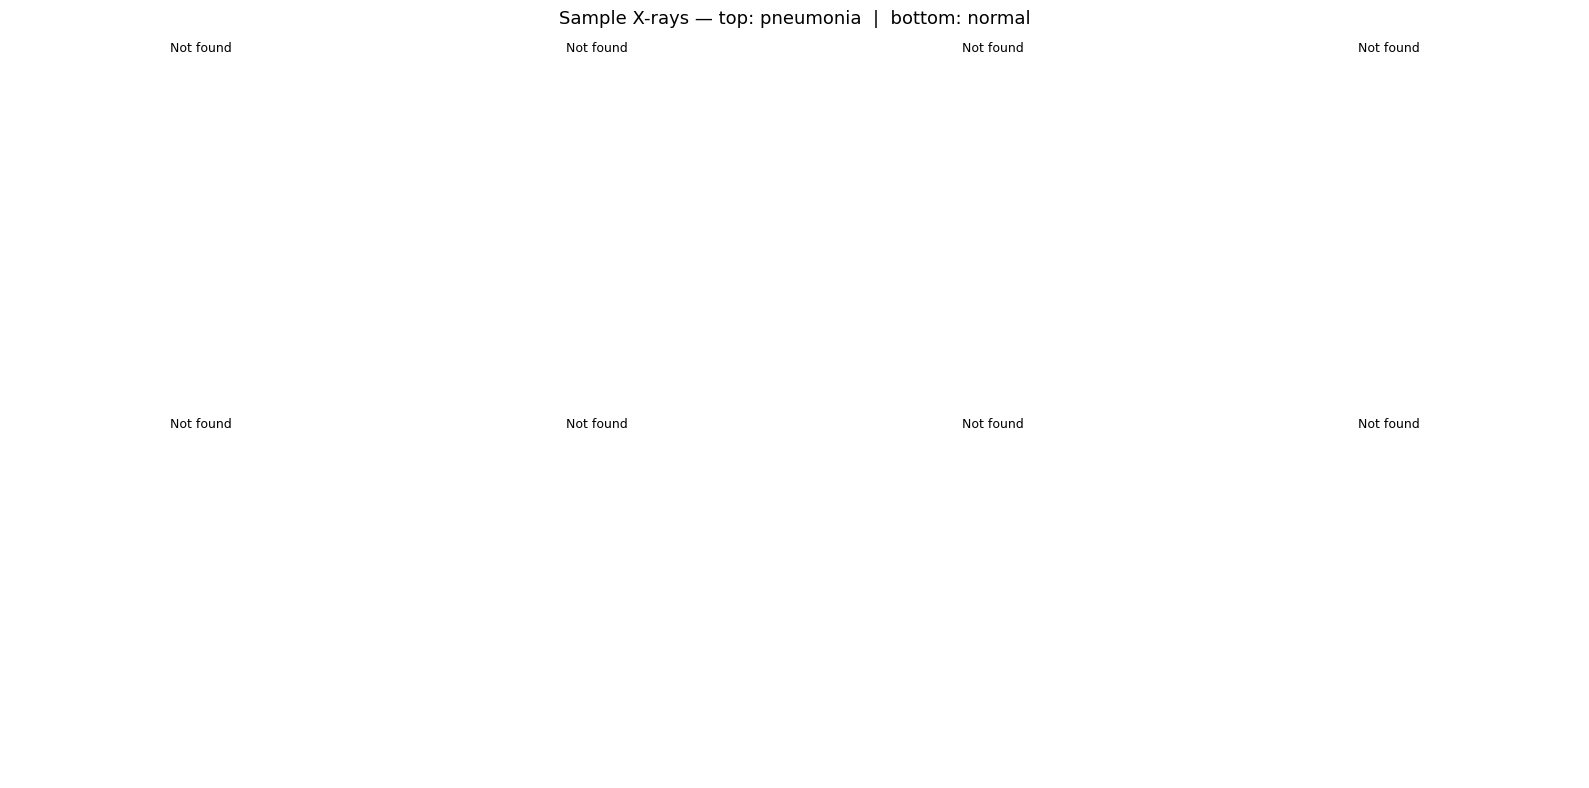

In [13]:
from PIL import Image
import matplotlib.patches as patches

def load_image(pid):
    for ext in ['jpg', 'jpeg', 'png']:
        path = f'{IMG_DIR}/{pid}.{ext}'
        if os.path.exists(path):
            return np.array(Image.open(path).convert('RGB'))
    raise FileNotFoundError(pid)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample X-rays — top: pneumonia  |  bottom: normal', fontsize=13)

for i, pid in enumerate(patients_pneumonia[:4]):
    try:
        img = load_image(pid)
        axes[0, i].imshow(img, cmap='gray')
        rows = df_filtered[(df_filtered['patientId'] == pid) & (df_filtered['Target'] == 1)]
        for _, row in rows.iterrows():
            if pd.notna(row['x']):
                rect = patches.Rectangle(
                    (row['x'], row['y']), row['width'], row['height'],
                    linewidth=2, edgecolor='red', facecolor='none'
                )
                axes[0, i].add_patch(rect)
        axes[0, i].set_title('Pneumonia', fontsize=10, color='red')
    except FileNotFoundError:
        axes[0, i].set_title('Not found', fontsize=9)
    axes[0, i].axis('off')

for i, pid in enumerate(patients_normal[:4]):
    try:
        img = load_image(pid)
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title('Normal', fontsize=10, color='#3B8BD4')
    except FileNotFoundError:
        axes[1, i].set_title('Not found', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 🔄 Step 7 — Convert to YOLO format

For each image:
- Copy JPEG to YOLO folder
- Write `.txt` label with normalized coordinates
- Normal images → empty `.txt`

In [14]:
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from PIL import Image
import cv2, os, numpy as np

# ✅ Paths صحيحين
IMG_DIR  = f'{DATA_DIR}/Training/Images'
MASK_DIR = f'{DATA_DIR}/Training/Masks'
MASK_DIR = f'{DATA_DIR}/Training/Masks'

YOLO_DIR = '/kaggle/working/pneumonia_yolo'
for split in ['train', 'val']:
    os.makedirs(f'{YOLO_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{YOLO_DIR}/labels/{split}', exist_ok=True)


def mask_to_yolo_boxes(mask_path, W, H):
    """Extract bounding boxes from white regions in mask."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    _, binary = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w * h < 100:   # skip tiny noise
            continue
        x_c = (x + w/2) / W
        y_c = (y + h/2) / H
        w_n = w / W
        h_n = h / H
        boxes.append((
            max(0, min(1, x_c)),
            max(0, min(1, y_c)),
            max(0, min(1, w_n)),
            max(0, min(1, h_n))
        ))
    return boxes


def convert_patient(pid, split):
    src_path  = f'{IMG_DIR}/{pid}.png'
    mask_path = f'{MASK_DIR}/{pid}.png'

    if not os.path.exists(src_path):
        return

    # Copy image
    img  = Image.open(src_path).convert('RGB')
    W, H = img.size
    img.save(f'{YOLO_DIR}/images/{split}/{pid}.jpg', quality=95)

    # Extract boxes from mask (if exists) else empty label = normal
    label_path = f'{YOLO_DIR}/labels/{split}/{pid}.txt'
    with open(label_path, 'w') as f:
        if os.path.exists(mask_path):
            boxes = mask_to_yolo_boxes(mask_path, W, H)
            for x_c, y_c, w_n, h_n in boxes:
                f.write(f'0 {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}\n')
        # no mask → empty file → normal class


# Stratified split
all_patients = np.concatenate([patients_pneumonia, patients_normal])
targets      = [1]*len(patients_pneumonia) + [0]*len(patients_normal)
train_pids, val_pids = train_test_split(
    all_patients, test_size=0.15, stratify=targets, random_state=42
)

print(f"Train: {len(train_pids)} | Val: {len(val_pids)}")

print("\n🔄 Converting train...")
for pid in tqdm(train_pids):
    convert_patient(pid, 'train')

print("\n🔄 Converting val...")
for pid in tqdm(val_pids):
    convert_patient(pid, 'val')

print(f"\n✅ Train images : {len(os.listdir(f'{YOLO_DIR}/images/train'))}")
print(f"✅ Val images   : {len(os.listdir(f'{YOLO_DIR}/images/val'))}")

# Verify one sample
sample_pid = train_pids[0]
label_file = f'{YOLO_DIR}/labels/train/{sample_pid}.txt'
print(f"\n🔍 Sample label ({sample_pid}):")
with open(label_file) as f:
    content = f.read()
    print(content if content else "(empty = normal)")

Train: 12633 | Val: 2230

🔄 Converting train...


  0%|          | 0/12633 [00:00<?, ?it/s]


🔄 Converting val...


  0%|          | 0/2230 [00:00<?, ?it/s]


✅ Train images : 12633
✅ Val images   : 2230

🔍 Sample label (b77ab795-de76-4715-b371-eb7be54b584c):
0 0.680176 0.690430 0.229492 0.158203
0 0.341797 0.643555 0.167969 0.183594



## ⚙️ Step 8 — YAML config

In [15]:
import yaml

config = {
    'path'  : YOLO_DIR,
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : 1,
    'names' : ['pneumonia']
}

YAML_PATH = f'{YOLO_DIR}/pneumonia.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("✅ YAML config:")
!cat {YAML_PATH}

✅ YAML config:
names:
- pneumonia
nc: 1
path: /kaggle/working/pneumonia_yolo
train: images/train
val: images/val


## 🚀 Step 9 — Train YOLOv8

> ⏱️ ~30–50 min on T4 GPU for 50 epochs.

`cls=2.0` → doubles the penalty on pneumonia misclassification to handle class imbalance.

In [16]:
# === DEBUG — شغّل هاد قبل training ===
import os

# 1. شوف شنو فعلاً فـ Training folder
print("📂 Training folder contents (first 10):")
training_files = os.listdir(IMG_DIR)
for f in training_files[:10]:
    print(' ', f)

print(f"\nTotal files in Training: {len(training_files)}")

# 2. شوف شكل الـ patientId
print(f"\n📋 Sample patientIds from CSV:")
for pid in list(patients_pneumonia[:3]):
    print(' ', pid)

# 3. شوف شنو فـ YOLO folder بعد الـ conversion
train_count = len(os.listdir(f'{YOLO_DIR}/images/train'))
val_count   = len(os.listdir(f'{YOLO_DIR}/images/val'))
print(f"\n📂 YOLO train images : {train_count}")
print(f"📂 YOLO val images   : {val_count}")

# 4. Try manually لـ patient واحد
pid = patients_pneumonia[0]
print(f"\n🔍 Testing pid: {pid}")
for ext in ['jpg', 'jpeg', 'png']:
    path = f'{IMG_DIR}/{pid}.{ext}'
    print(f"  {path} → exists: {os.path.exists(path)}")

# 5. Check if Training has subfolders
for item in training_files[:5]:
    full = f'{IMG_DIR}/{item}'
    print(f"\n  {item} → isdir: {os.path.isdir(full)}")
    if os.path.isdir(full):
        sub = os.listdir(full)
        print(f"    contents: {sub[:5]}")

📂 Training folder contents (first 10):
  7a530f4d-13af-4e4e-bf2e-080c7fb27ffb.png
  86f084ef-539c-404b-9a91-c9a5d5ab3771.png
  673989cb-131a-43fc-8276-710c65ddb2d6.png
  85a77a2c-9fb8-4ceb-af2b-4de716d4d366.png
  9f756055-99fc-4a80-97b4-f89f98cf92d2.png
  799c13e6-dff4-4c52-9aaf-b9ea6daeacb1.png
  ff68830c-84cf-44c5-983d-6d332f86d82a.png
  a67dee22-6255-4c02-b0d2-d3cc0903c833.png
  d3beb0ea-ec3c-4060-ab7c-6a7d00a3747e.png
  39ebb0a8-3fad-42c6-83d1-b92272c32f6f.png

Total files in Training: 26684

📋 Sample patientIds from CSV:
  00436515-870c-4b36-a041-de91049b9ab4
  00704310-78a8-4b38-8475-49f4573b2dbb
  00aecb01-a116-45a2-956c-08d2fa55433f

📂 YOLO train images : 12633
📂 YOLO val images   : 2230

🔍 Testing pid: 00436515-870c-4b36-a041-de91049b9ab4
  /kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset/Training/Images/00436515-870c-4b36-a041-de91049b9ab4.jpg → exists: False
  /kaggle/input/datasets/iamtapendu/rsna-pneumonia-processed-dataset/Training/Images/00436515-870c-4

In [18]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data     = YAML_PATH,
    epochs   = 50,
    imgsz    = 640,
    batch    = 64,   # P100 16GB → can handle batch 32
    device   = '0,1',
    patience = 10,
    lr0      = 0.001,
    lrf      = 0.01,
    cls      = 2.0,    # handle class imbalance
    flipud   = 0.0,    # X-rays don't flip vertically
    fliplr   = 0.5,
    degrees  = 5,
    scale    = 0.3,
    hsv_s    = 0.0,    # grayscale images — no saturation
    hsv_h    = 0.0,
    project  = '/kaggle/working/runs',
    name     = 'pneumonia',
    exist_ok = True,
    verbose  = True
)

BEST_MODEL = '/kaggle/working/runs/pneumonia/weights/best.pt'
print(f"\n✅ Training complete — best model: {BEST_MODEL}")

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pneumonia_yolo/pneumonia.yaml, degrees=5, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pneumoni

## 📈 Step 10 — Training curves

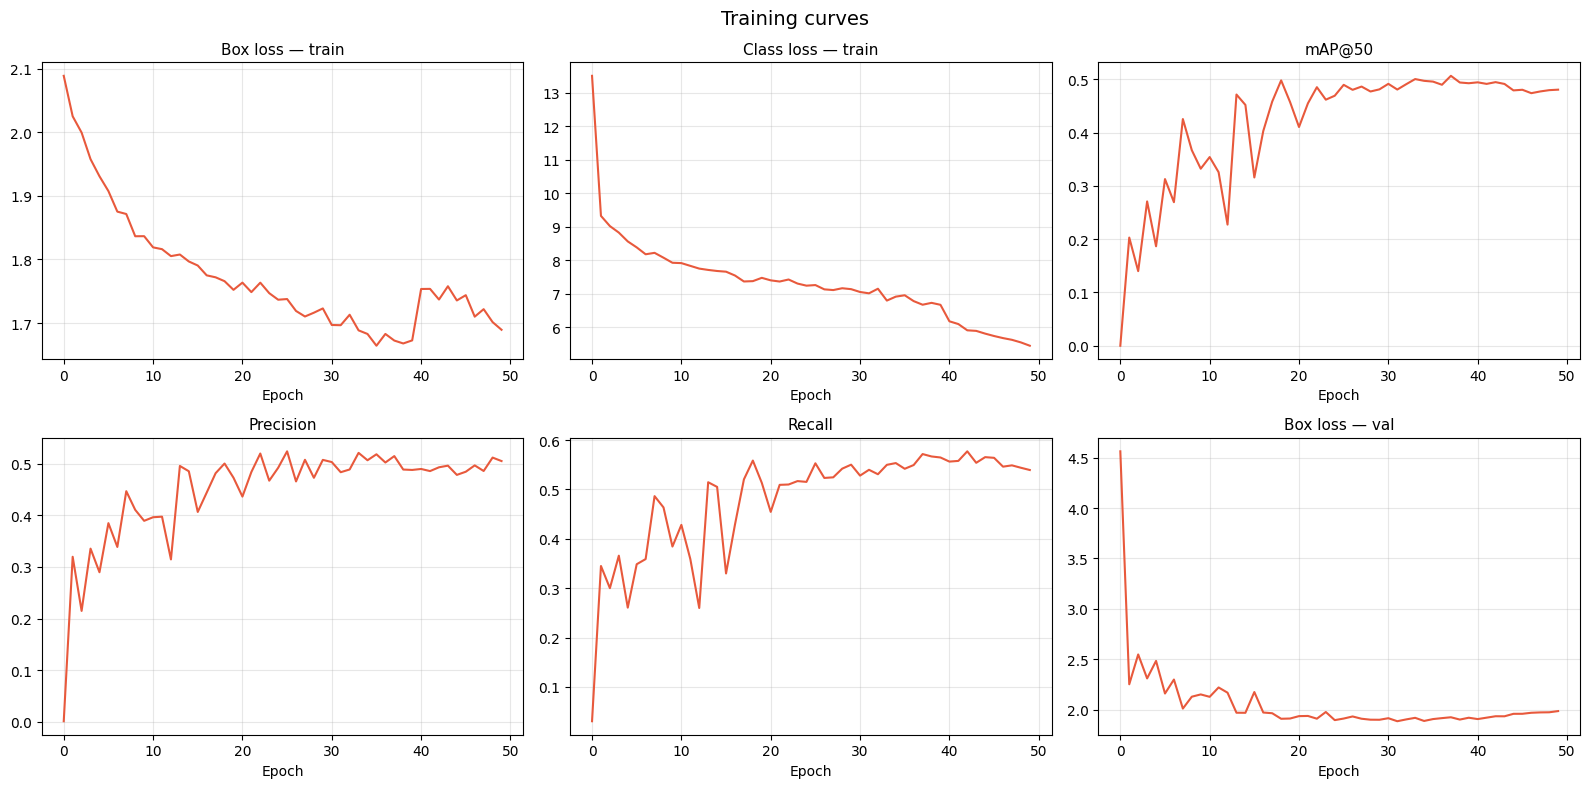

In [19]:
df_res = pd.read_csv('/kaggle/working/runs/pneumonia/results.csv')
df_res.columns = df_res.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Training curves', fontsize=14)

metrics = [
    ('train/box_loss',       'Box loss — train',  axes[0,0]),
    ('train/cls_loss',       'Class loss — train', axes[0,1]),
    ('metrics/mAP50(B)',     'mAP@50',             axes[0,2]),
    ('metrics/precision(B)', 'Precision',          axes[1,0]),
    ('metrics/recall(B)',    'Recall',             axes[1,1]),
    ('val/box_loss',         'Box loss — val',     axes[1,2]),
]

for col, title, ax in metrics:
    if col in df_res.columns:
        ax.plot(df_res[col], color='#E8593C', linewidth=1.5)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{title} — not found', fontsize=10)

plt.tight_layout()
plt.show()

## 📊 Step 11 — Evaluate on validation set

In [20]:
best_model = YOLO(BEST_MODEL)

val_results = best_model.val(
    data    = YAML_PATH,
    imgsz   = 640,
    conf    = 0.25,
    iou     = 0.5,
    verbose = True
)

print(f"\n{'='*40}")
print(f"mAP@50    : {val_results.box.map50:.4f}")
print(f"mAP@50-95 : {val_results.box.map:.4f}")
print(f"Precision : {val_results.box.mp:.4f}")
print(f"Recall    : {val_results.box.mr:.4f}")
print(f"{'='*40}")

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3617.7±929.0 MB/s, size: 205.9 KB)
val: Scanning /kaggle/working/pneumonia_yolo/labels/val.cache... 2230 images, 1328 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2230/2230 322.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 140/140 5.7it/s 24.6s0.2s
                   all       2230       1443      0.636      0.434      0.315      0.124
Speed: 0.8ms preprocess, 8.5ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

mAP@50    : 0.3153
mAP@50-95 : 0.1240
Precision : 0.6355
Recall    : 0.4338


## 🔥 Step 12 — Grad-CAM setup

Grad-CAM runs on the **same YOLOv8 model** — no extra model needed.
The heatmap style matches medical literature: blue-tinted X-ray background + JET hot spots.

In [22]:
import torch
import cv2
import numpy as np
from ultralytics import YOLO

best_model = YOLO(BEST_MODEL)
torch_model = best_model.model
torch_model.eval()

activations = []

def save_activation(module, input, output):
    activations.append(output.detach())

# Hook on the last backbone convolutional block
target_layer = torch_model.model[-2]
target_layer.register_forward_hook(save_activation)


def compute_gradcam(img_path):
    """Return (img_rgb original size, heatmap normalized 0-1)."""
    activations.clear()

    img_bgr     = cv2.imread(img_path)
    img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (640, 640))

    tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
    tensor = tensor.unsqueeze(0).requires_grad_(True)

    with torch.enable_grad():
        output = torch_model(tensor)
        score  = output[0].sum() if isinstance(output, (list, tuple)) else output.sum()
        torch_model.zero_grad()
        score.backward()

    act     = activations[0].cpu().numpy()[0]           # (C, H, W)
    weights = np.mean(act, axis=(1, 2))                 # (C,)
    cam     = np.zeros(act.shape[1:], dtype=np.float32) # (H, W)
    for i, w in enumerate(weights):
        cam += w * act[i]

    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / cam.max()

    heatmap = cv2.resize(cam, (img_rgb.shape[1], img_rgb.shape[0]))
    return img_rgb, heatmap


def overlay_gradcam(img_rgb, heatmap, boxes=None):
    """
    Medical-style overlay:
    - Blue-tinted grayscale X-ray as background
    - JET heatmap blended on top (hot = red/orange, cold = blue)
    - Bounding boxes drawn last
    """
    # 1. Grayscale X-ray → blue-tinted background (like the reference image)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blue_bg = np.zeros_like(img_rgb)
    blue_bg[:, :, 0] = (gray * 0.4).astype(np.uint8)   # R — low
    blue_bg[:, :, 1] = (gray * 0.5).astype(np.uint8)   # G — medium
    blue_bg[:, :, 2] = (gray * 0.9).astype(np.uint8)   # B — high → blue tint

    # 2. JET heatmap
    heatmap_jet = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_jet, cv2.COLOR_BGR2RGB)

    # 3. Blend: blue background + heatmap
    result = cv2.addWeighted(blue_bg, 0.35, heatmap_rgb, 0.65, 0)

    # 4. Bounding boxes on top
    if boxes:
        for box in boxes:
            x1, y1, x2, y2, conf = int(box[0]), int(box[1]), int(box[2]), int(box[3]), box[4]
            cv2.rectangle(result, (x1, y1), (x2, y2), (255, 255, 255), 2)
            label = f'Pneumonia {conf:.0%}'
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(result, (x1, max(y1-th-8, 0)), (x1+tw+4, y1), (255,255,255), -1)
            cv2.putText(result, label, (x1+2, max(y1-4, th)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (30, 30, 30), 2)
    return result


print("✅ Grad-CAM functions ready")

✅ Grad-CAM functions ready


## 🩺 Step 13 — Inference + Grad-CAM on validation samples

Grad-CAM error for 22e76fb4-c74e-4cc3-820a-832a4467dac6: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor
Grad-CAM error for 70d7f4df-5497-4205-a36b-e47b58145fa2: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor
Grad-CAM error for 90cfaf6d-0247-4431-be9b-bca6c060e394: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor


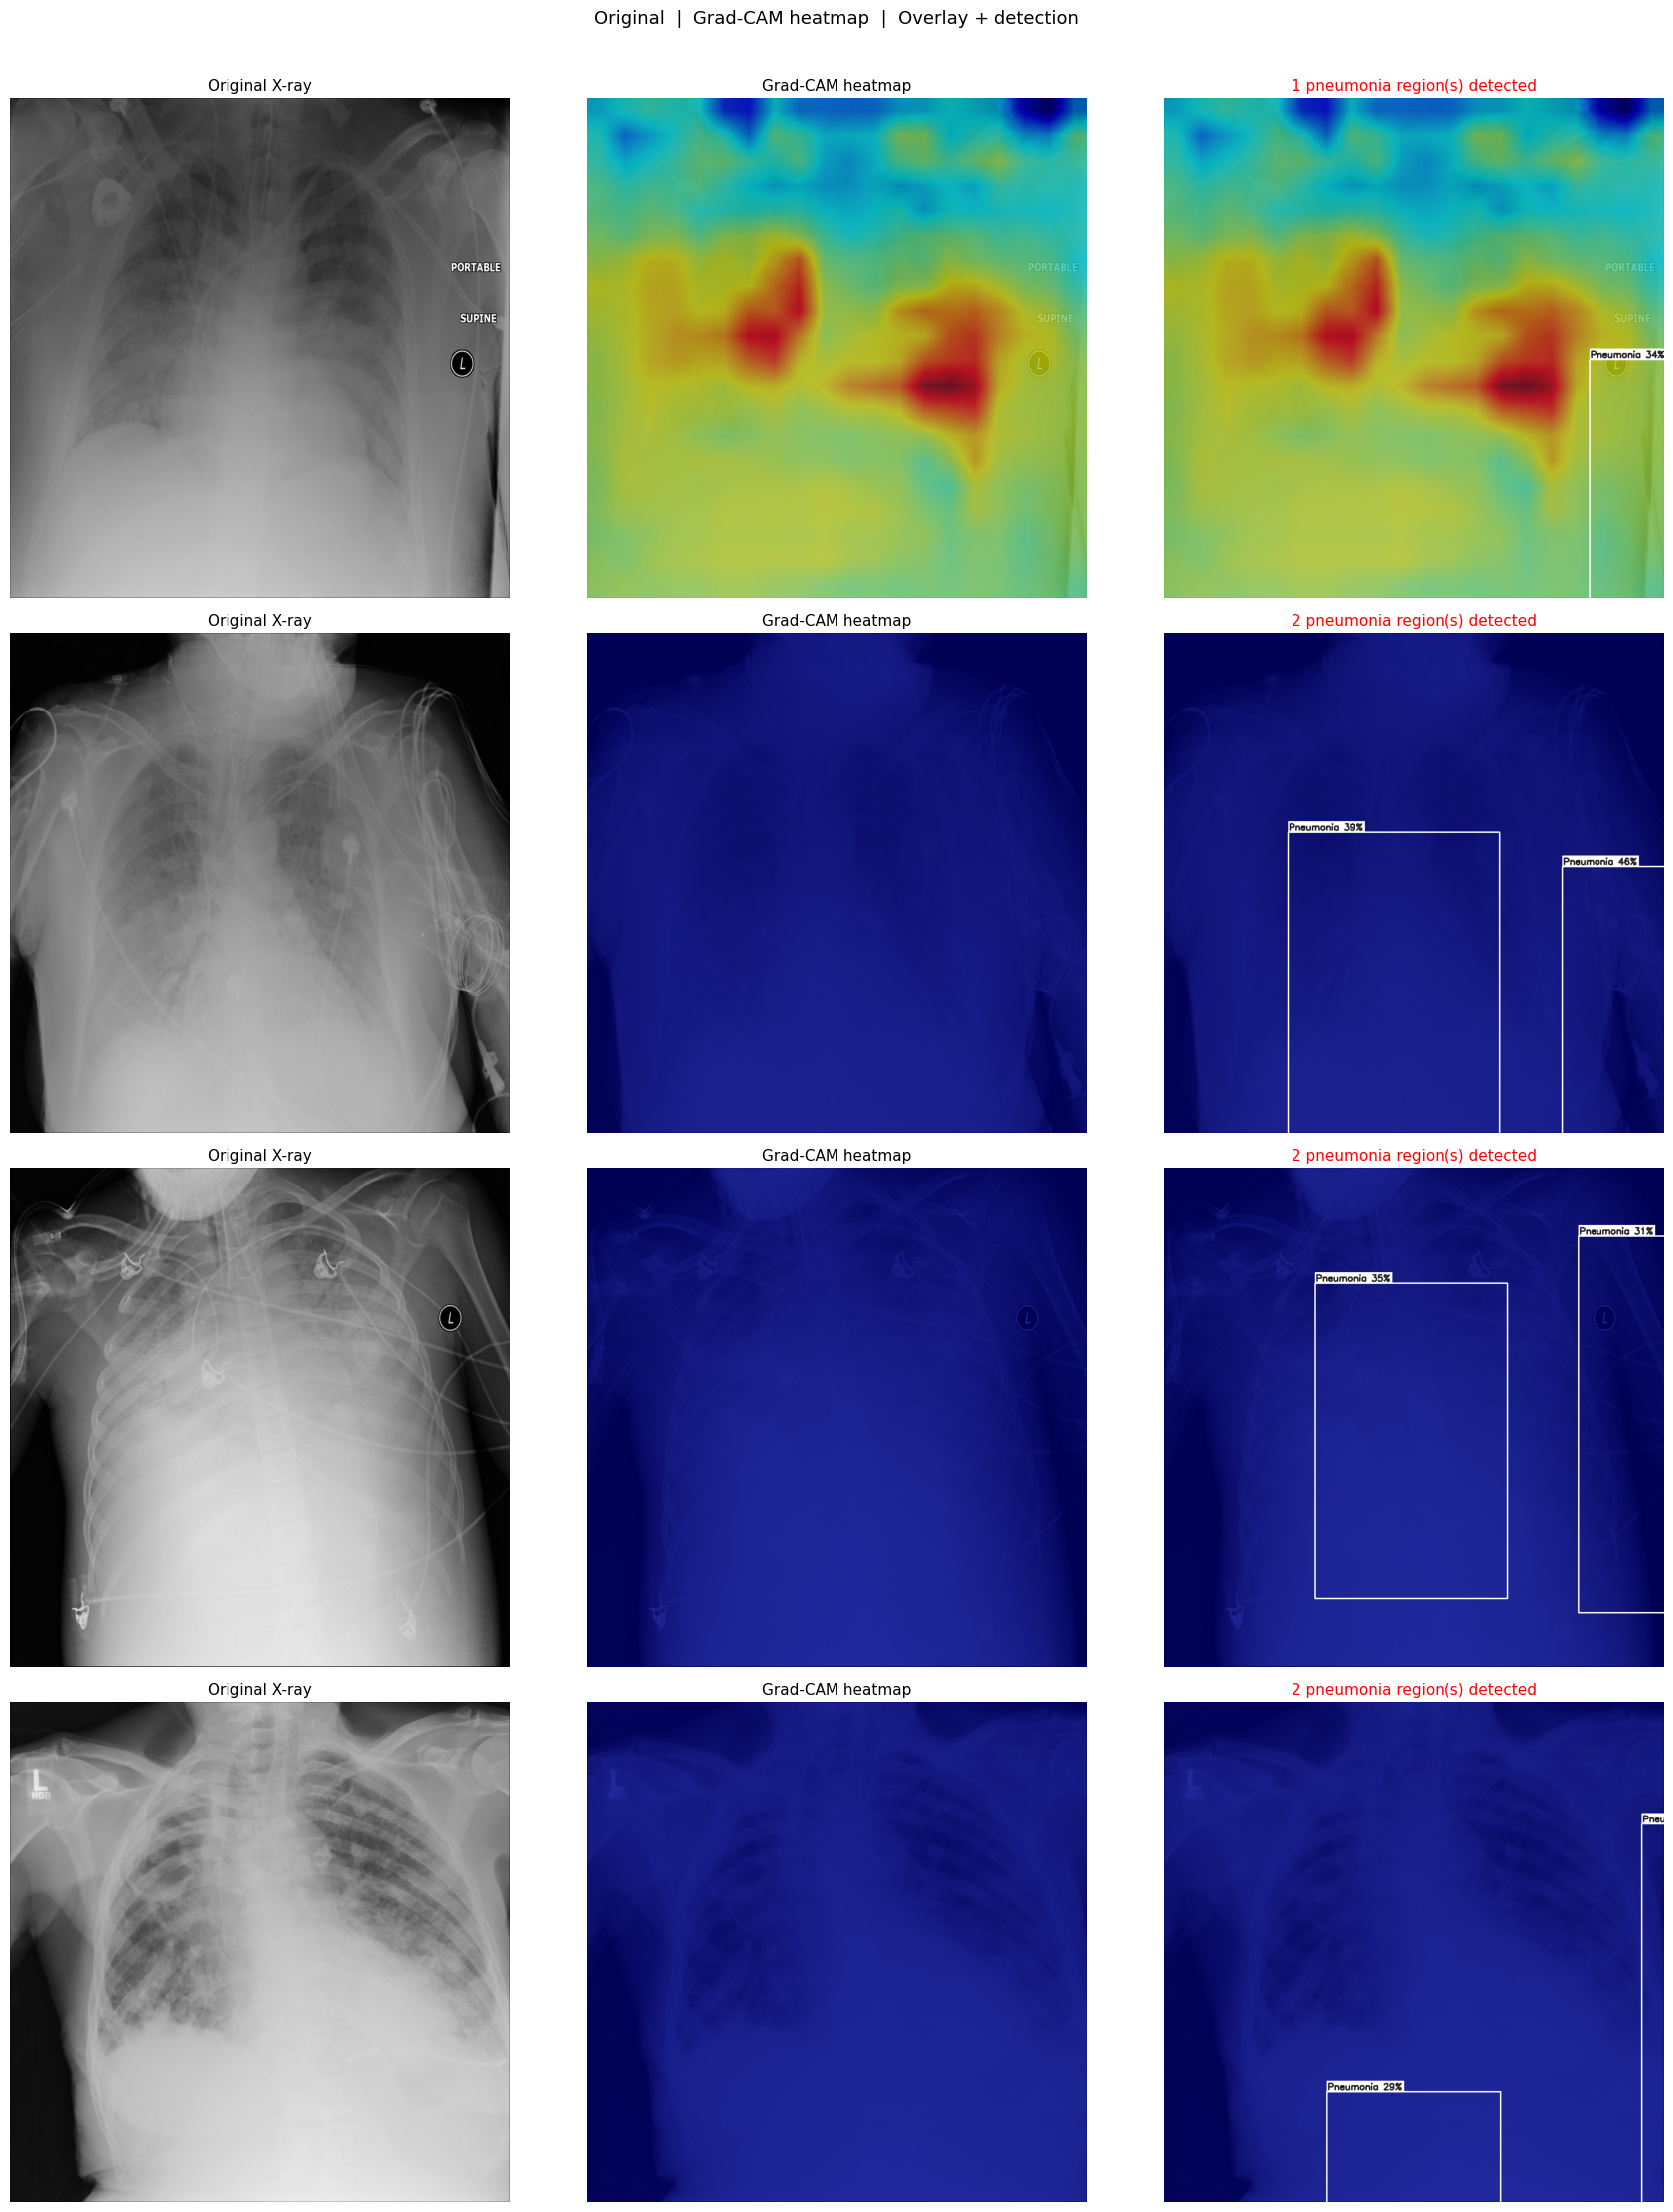

In [23]:
# Pick 4 pneumonia patients from val set
pneumonia_val_pids = [
    pid for pid in val_pids if pid in patients_pneumonia
][:4]

if not pneumonia_val_pids:
    print("⚠️ No pneumonia patients found in val set — using first 4 val images")
    pneumonia_val_pids = list(val_pids[:4])

fig, axes = plt.subplots(len(pneumonia_val_pids), 3,
                         figsize=(18, 5.5 * len(pneumonia_val_pids)))
if len(pneumonia_val_pids) == 1:
    axes = [axes]

fig.suptitle('Original  |  Grad-CAM heatmap  |  Overlay + detection',
             fontsize=13, y=1.01)

for i, pid in enumerate(pneumonia_val_pids):
    img_path = f'{YOLO_DIR}/images/val/{pid}.jpg'
    if not os.path.exists(img_path):
        continue

    # Col 0 — original X-ray
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    axes[i][0].imshow(img_rgb, cmap='gray')
    axes[i][0].set_title('Original X-ray', fontsize=11)
    axes[i][0].axis('off')

    # Compute Grad-CAM
    try:
        _, heatmap = compute_gradcam(img_path)
    except Exception as e:
        print(f'Grad-CAM error for {pid}: {e}')
        heatmap = np.zeros((img_rgb.shape[0], img_rgb.shape[1]))

    # Col 1 — heatmap only (medical blue style)
    gray    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blue_bg = np.zeros_like(img_rgb)
    blue_bg[:,:,0] = (gray * 0.4).astype(np.uint8)
    blue_bg[:,:,1] = (gray * 0.5).astype(np.uint8)
    blue_bg[:,:,2] = (gray * 0.9).astype(np.uint8)
    heatmap_jet = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_jet, cv2.COLOR_BGR2RGB)
    heatmap_vis = cv2.addWeighted(blue_bg, 0.35, heatmap_rgb, 0.65, 0)
    axes[i][1].imshow(heatmap_vis)
    axes[i][1].set_title('Grad-CAM heatmap', fontsize=11)
    axes[i][1].axis('off')

    # Col 2 — YOLO detection + full overlay
    preds  = best_model.predict(img_path, conf=0.25, verbose=False)
    boxes  = []
    h0, w0 = img_rgb.shape[:2]
    if len(preds[0].boxes) > 0:
        for b in preds[0].boxes:
            x1, y1, x2, y2 = b.xyxy[0].cpu().numpy()
            conf = float(b.conf[0])
            boxes.append([
                x1 * w0/640, y1 * h0/640,
                x2 * w0/640, y2 * h0/640, conf
            ])

    final = overlay_gradcam(img_rgb, heatmap, boxes if boxes else None)
    axes[i][2].imshow(final)
    title = f'{len(boxes)} pneumonia region(s) detected' if boxes else 'No detection'
    axes[i][2].set_title(title, fontsize=11,
                         color='red' if boxes else 'green')
    axes[i][2].axis('off')

plt.tight_layout()
plt.show()

## 💾 Step 14 — Download best model

In [24]:
import shutil

# ✅ On Kaggle — model is auto-saved to output
# Just copy to /kaggle/working/ and it appears in Output tab
shutil.copy(BEST_MODEL, '/kaggle/working/pneumonia_best.pt')
print("✅ Model saved to /kaggle/working/pneumonia_best.pt")
print("   Go to: Output tab → Download")

✅ Model saved to /kaggle/working/pneumonia_best.pt
   Go to: Output tab → Download


## 🔮 Step 15 — Predict on any X-ray

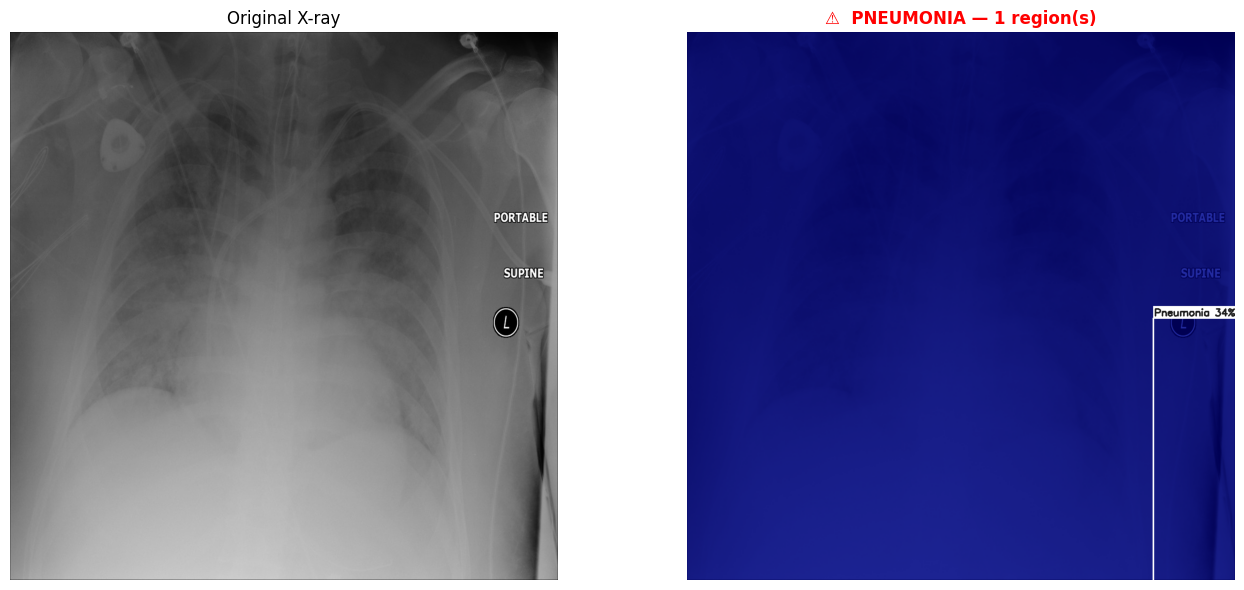

[[np.float32(871.9344),
  np.float32(534.94934),
  np.float32(1315.8549),
  np.float32(1261.2405),
  0.33962705731391907]]

In [25]:
def predict_xray(img_path, conf=0.25):
    """Run full pipeline on any X-ray: detection + Grad-CAM overlay."""
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h0, w0  = img_rgb.shape[:2]

    preds      = best_model.predict(img_path, conf=conf, verbose=False)
    boxes_data = []

    if len(preds[0].boxes) > 0:
        title_text  = f'⚠️  PNEUMONIA — {len(preds[0].boxes)} region(s)'
        title_color = 'red'
        for b in preds[0].boxes:
            x1, y1, x2, y2 = b.xyxy[0].cpu().numpy()
            boxes_data.append([
                x1*w0/640, y1*h0/640,
                x2*w0/640, y2*h0/640,
                float(b.conf[0])
            ])
    else:
        title_text  = '✅  NORMAL — no pneumonia detected'
        title_color = 'green'

    try:
        _, heatmap = compute_gradcam(img_path)
    except:
        heatmap = np.zeros((h0, w0))

    result = overlay_gradcam(img_rgb, heatmap, boxes_data if boxes_data else None)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(img_rgb, cmap='gray')
    axes[0].set_title('Original X-ray', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(result)
    axes[1].set_title(title_text, fontsize=12,
                      color=title_color, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    return boxes_data


# Test on a val image
sample = f'{YOLO_DIR}/images/val/{val_pids[0]}.jpg'
predict_xray(sample)

---
## ✅ Summary

| Step | Status |
|------|--------|
| Dataset download (kagglehub) | ✅ |
| CSV filtering (Lung Opacity / Normal) | ✅ |
| JPEG → YOLO format conversion | ✅ |
| Class imbalance (cls=2.0) | ✅ |
| YOLOv8s training (50 epochs) | ✅ |
| mAP / Precision / Recall evaluation | ✅ |
| Grad-CAM heatmap (medical blue style) | ✅ |
| Bounding box overlay | ✅ |
| Model export | ✅ |

**Next step:** Flask web app — upload X-ray → get detection + heatmap in browser.